In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 1. Data Loading and Preprocessing

In [ ]:
df = pd.read_csv("/content/Dataset.csv")
df.head()

,Crop_Type,Fertilizer_Type,Nitrogen_kg_ha,Irrigation_Method,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,CO2_kg_ha,CH4_kg_ha,N2O_kg_ha,Total_GHG_kgCO2e,Scenario_Type,Intervention_Type
0,Soybean,Synthetic,232.998485,Sprinkler,798.658484,13.900466,487.193424,42.904181,660.659923,3.832290,2.935502,1631.246917,Baseline,NaN
1,Soybean,Synthetic,141.237938,Sprinkler,713.986285,15.732909,487.193424,42.904181,588.493009,2.439946,1.520592,1102.628022,Counterfactual,Reduced_Input
2,Soybean,Synthetic,161.065486,Sprinkler,642.881174,15.332411,487.193424,42.904181,528.132205,2.406290,2.177719,1237.249832,Counterfactual,Reduced_Input
3,Soybean,Synthetic,160.219869,Sprinkler,617.580538,15.356536,487.193424,42.904181,514.285435,2.693513,1.733796,1098.294460,Counterfactual,Reduced_Input
4,Rice,Mixed,201.886213,Flood,370.524124,11.626290,1438.662645,88.281602,315.108046,15.000000,2.122508,1322.615320,Baseline,NaN


In [ ]:
print('Number of rows in the dataset: ', df.shape[0])
print('Number of columns in the dataset: ', df.shape[1])

Number of rows in the dataset:  40000
Number of columns in the dataset:  14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop_Type            40000 non-null  object 
 1   Fertilizer_Type      40000 non-null  object 
 2   Nitrogen_kg_ha       40000 non-null  float64
 3   Irrigation_Method    40000 non-null  object 
 4   Irrigation_Water_mm  40000 non-null  float64
 5   Avg_Temperature_C    40000 non-null  float64
 6   Rainfall_mm          40000 non-null  float64
 7   Humidity_%           40000 non-null  float64
 8   CO2_kg_ha            40000 non-null  float64
 9   CH4_kg_ha            40000 non-null  float64
 10  N2O_kg_ha            40000 non-null  float64
 11  Total_GHG_kgCO2e     40000 non-null  float64
 12  Scenario_Type        40000 non-null  object 
 13  Intervention_Type    30000 non-null  object 
dtypes: float64(9), object(5)
memory usage: 4.3+ MB


In [ ]:
numerical_vars = df.select_dtypes(include=['int64', 'float64'])
categorical_vars = df.select_dtypes(include=['object', 'category'])
print("Numerical columns:", numerical_vars.columns.tolist())
print("Categorical columns:", categorical_vars.columns.tolist())

Numerical columns: ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C', 'Rainfall_mm', 'Humidity_%', 'CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha', 'Total_GHG_kgCO2e']
Categorical columns: ['Crop_Type', 'Fertilizer_Type', 'Irrigation_Method', 'Scenario_Type', 'Intervention_Type']


In [ ]:
missing_values = df['Intervention_Type'].value_counts()
print(missing_values)

Intervention_Type
Reduced_Input    30000
Name: count, dtype: int64


10000 rows in the dataset have Intervention_Type field given as null. We can change these values to an unknown value, so that we do not lose data.

In [ ]:
df['Intervention_Type'].fillna('Unknown', inplace=True)
df.head()

/tmp/ipython-input-2981/3443693523.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Intervention_Type'].fillna('Unknown', inplace=True)


,Crop_Type,Fertilizer_Type,Nitrogen_kg_ha,Irrigation_Method,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,CO2_kg_ha,CH4_kg_ha,N2O_kg_ha,Total_GHG_kgCO2e,Scenario_Type,Intervention_Type
0,Soybean,Synthetic,232.998485,Sprinkler,798.658484,13.900466,487.193424,42.904181,660.659923,3.832290,2.935502,1631.246917,Baseline,Unknown
1,Soybean,Synthetic,141.237938,Sprinkler,713.986285,15.732909,487.193424,42.904181,588.493009,2.439946,1.520592,1102.628022,Counterfactual,Reduced_Input
2,Soybean,Synthetic,161.065486,Sprinkler,642.881174,15.332411,487.193424,42.904181,528.132205,2.406290,2.177719,1237.249832,Counterfactual,Reduced_Input
3,Soybean,Synthetic,160.219869,Sprinkler,617.580538,15.356536,487.193424,42.904181,514.285435,2.693513,1.733796,1098.294460,Counterfactual,Reduced_Input
4,Rice,Mixed,201.886213,Flood,370.524124,11.626290,1438.662645,88.281602,315.108046,15.000000,2.122508,1322.615320,Baseline,Unknown


We can drop the columns CO2_kg_ha, CH4_kg_ha and N2O_kg_ha, because these fields have been incorporated in the Total_GHG_kgCO2e field

In [ ]:
df = df.drop(columns=['CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha'])

num_features = []
for column in df.columns:
  if df[column].dtype == 'float64':
    num_features.append(column)

num_df = df[num_features]
print("The regression target is the 'Total_GHG_kgCO2e' field\n")
print('The columns used for regression analysis: ')
for i in num_df.columns:
  print('\t', i)

The regression target is the 'Total_GHG_kgCO2e' field

The columns used for regression analysis: 
	 Nitrogen_kg_ha
	 Irrigation_Water_mm
	 Avg_Temperature_C
	 Rainfall_mm
	 Humidity_%
	 Total_GHG_kgCO2e


The component columns `CO2_kg_ha`, `CH4_kg_ha`, and `N2O_kg_ha` are **excluded** as inputs because they are sub-components of the target variable `Total_GHG_kgCO2e` — including them would cause data leakage. Categorical variables (Crop_Type, Fertilizer_Type, etc.) are also excluded as all models are implemented using numerical operations only

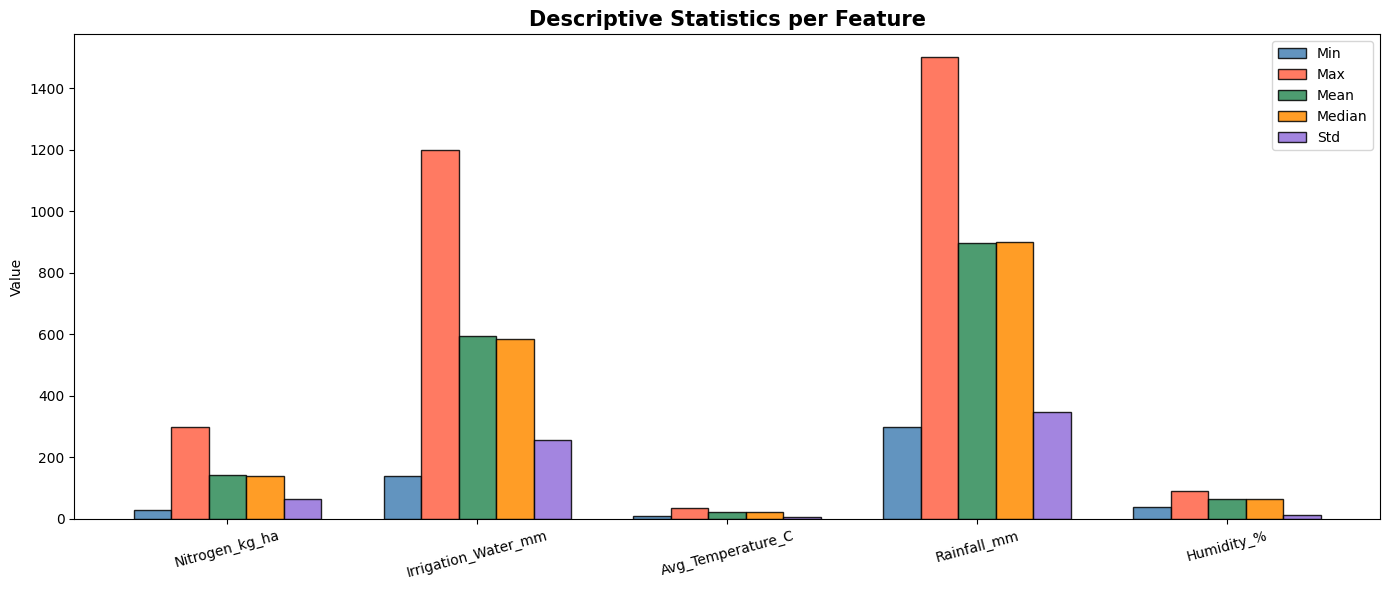

In [ ]:
# Bar chart: min, max, mean, median, std for each numerical feature
stats = num_df[num_features[:-1]].agg(['min', 'max', 'mean', 'median', 'std'])

x = np.arange(len(num_features[:-1]))
width = 0.15
stat_labels = ['min', 'max', 'mean', 'median', 'std']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (stat, color) in enumerate(zip(stat_labels, colors)):
    ax.bar(x + i * width, stats.loc[stat], width=width, label=stat.capitalize(),
           color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(num_features[:-1], rotation=15, fontsize=10)
ax.set_title('Descriptive Statistics per Feature', fontsize=15, fontweight='bold')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

The regression target (dependent variable) is Total_GHG_kgCO2e

In [ ]:
missing_values = num_df.isnull().sum()
print(missing_values)

Nitrogen_kg_ha         0
Irrigation_Water_mm    0
Avg_Temperature_C      0
Rainfall_mm            0
Humidity_%             0
Total_GHG_kgCO2e       0
dtype: int64


In [ ]:
print(num_df.describe())

       Nitrogen_kg_ha  Irrigation_Water_mm  Avg_Temperature_C   Rainfall_mm  \
count    40000.000000         40000.000000       40000.000000  40000.000000   
mean       142.765778           593.846482          23.444599    896.385823   
std         63.900585           255.983963           7.154821    346.103652   
min         30.613614           140.869913          10.002934    300.063392   
25%         89.472766           377.689330          17.350469    593.812110   
50%        139.421300           585.129210          23.287816    900.339261   
75%        189.122386           794.016279          29.524868   1192.976798   
max        299.971299          1199.878798          36.949406   1499.774383   

         Humidity_%  Total_GHG_kgCO2e  
count  40000.000000      40000.000000  
mean      65.242157       1083.554666  
std       14.428698        345.869022  
min       40.006735         74.320022  
25%       52.875921        836.134735  
50%       65.244394       1065.019298  
75%     

# 2. Exploratory Data Analysis (EDA)

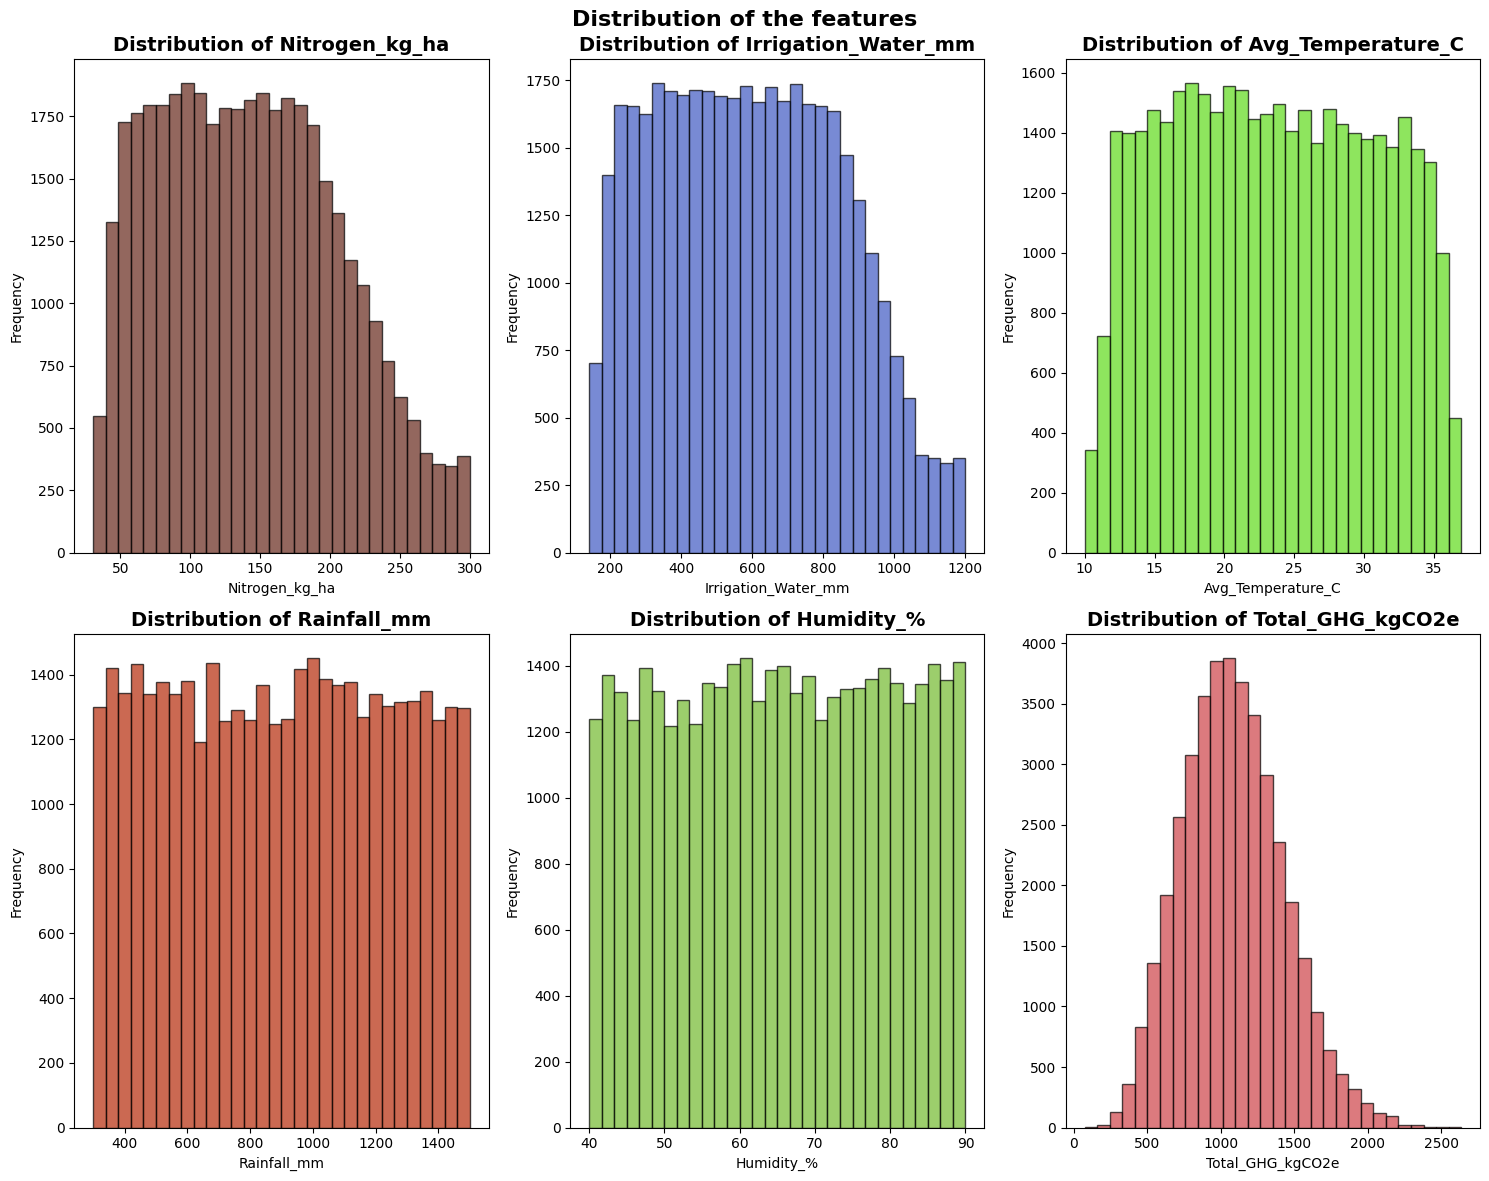

In [ ]:
fig, axes = plt.subplots(2, 3)
fig.set_size_inches(15, 12)
fig.suptitle('Distribution of the features', fontweight='bold', fontsize=16)

for idx, feature in enumerate(num_features):
  row = idx // 3
  col = idx % 3
  color = (random.randint(0,255)/255, random.randint(0,255)/255, random.randint(0,255)/255)
  axes[row, col].hist(num_df[feature], alpha=0.7, color=color, edgecolor='black', bins=30)
  axes[row, col].set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
  axes[row, col].set_xlabel(feature)
  axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

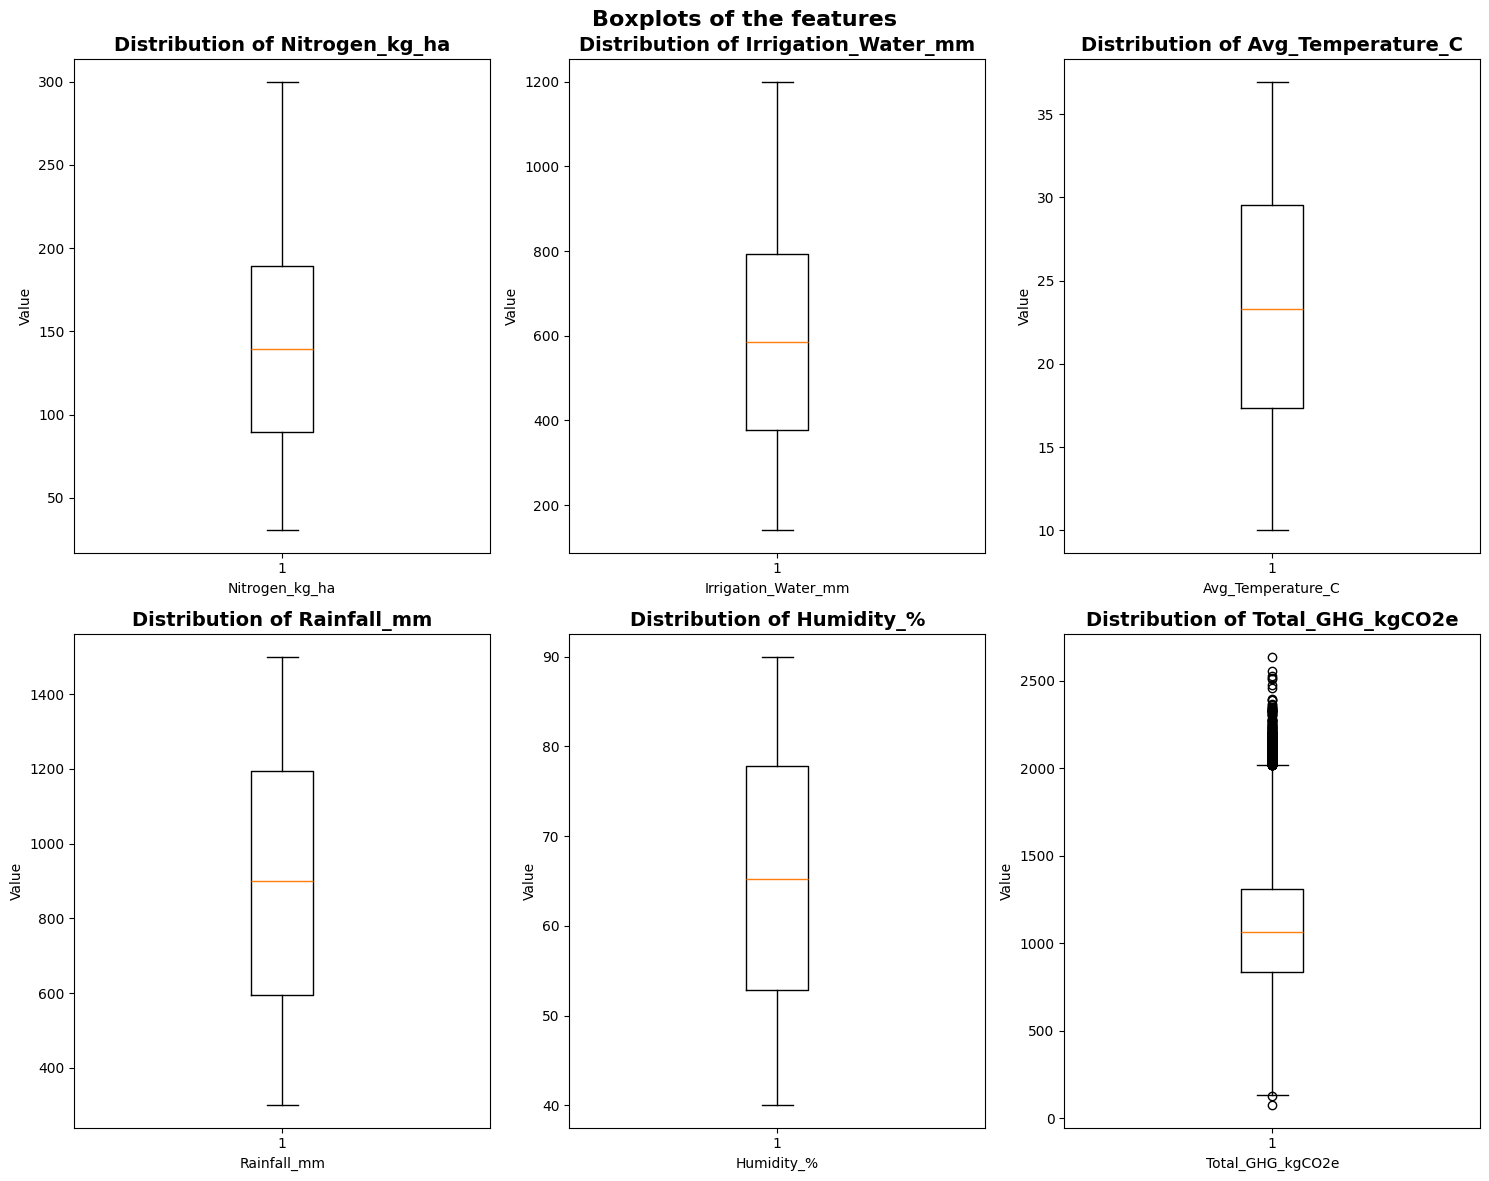

In [ ]:
fig, axes = plt.subplots(2, 3)
fig.set_size_inches(15, 12)
fig.suptitle('Boxplots of the features', fontweight='bold', fontsize=16)

for idx, feature in enumerate(num_features):
  row = idx // 3
  col = idx % 3
  axes[row, col].boxplot(df[feature])
  axes[row, col].set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
  axes[row, col].set_xlabel(feature)
  axes[row, col].set_ylabel('Value')

plt.tight_layout()
plt.show()

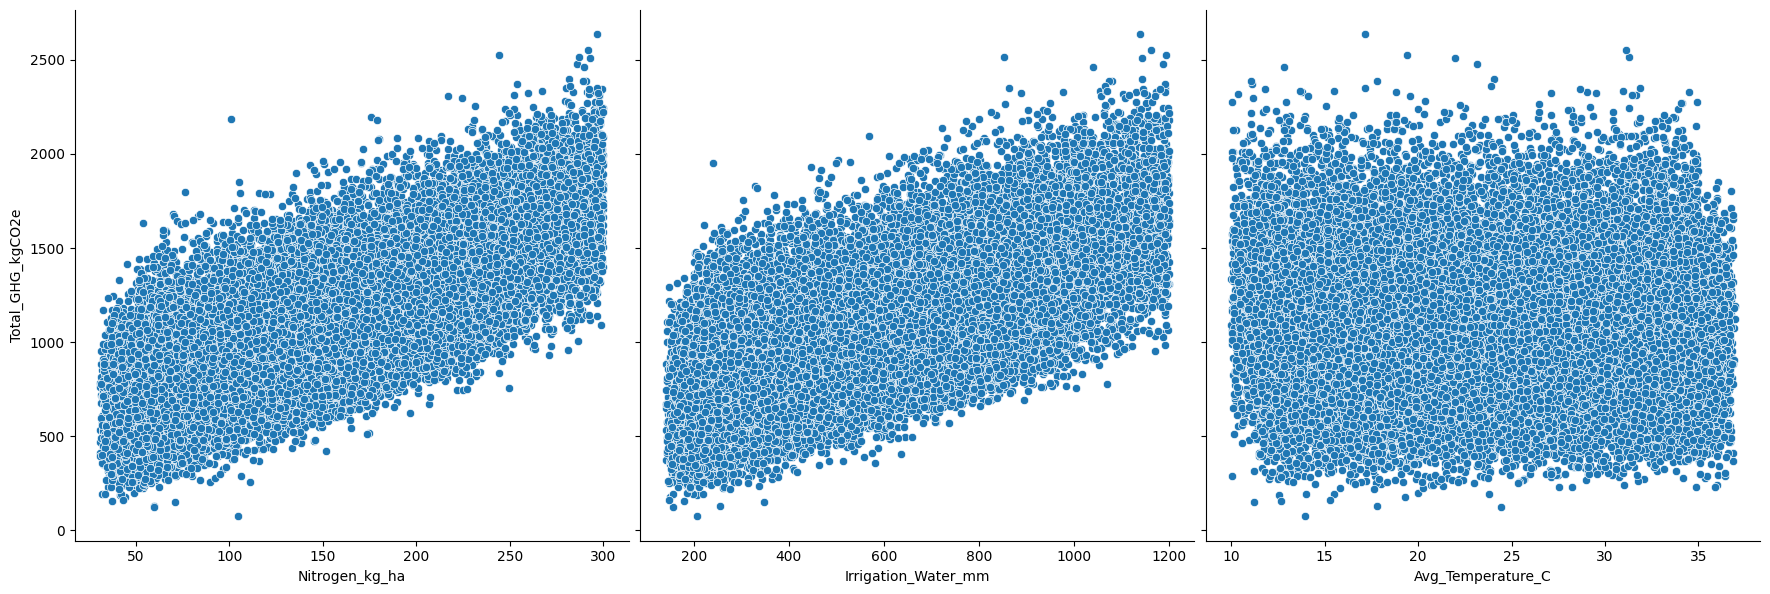

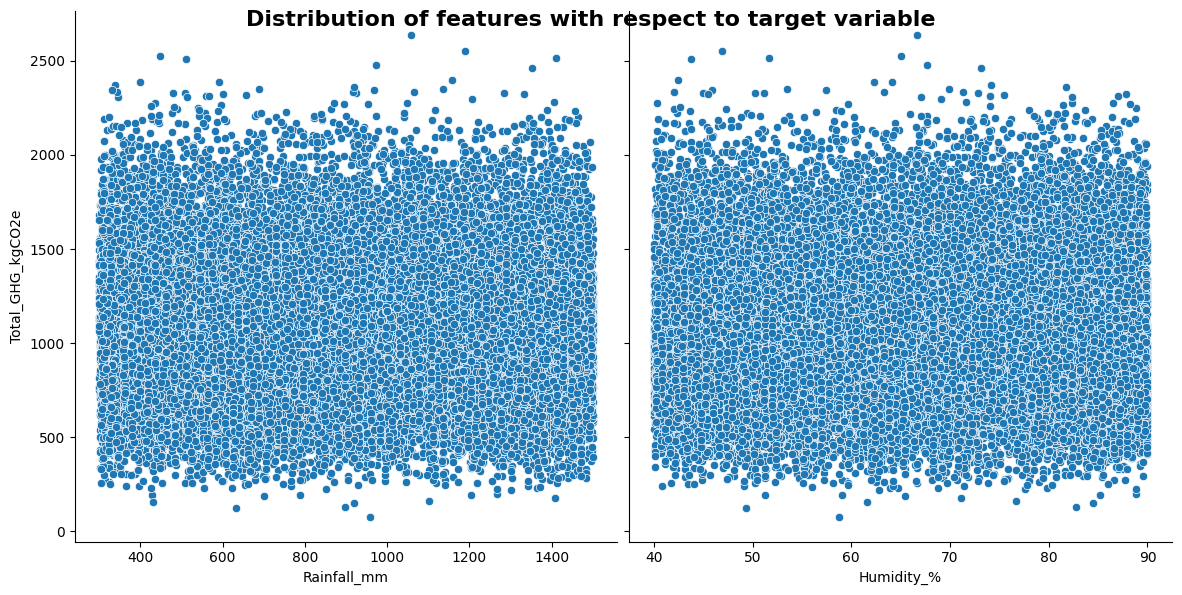

In [ ]:
sns.pairplot(num_df, x_vars=num_features[:3], y_vars=num_features[-1:], height=6, kind='scatter')
sns.pairplot(num_df, x_vars=num_features[3:-1], y_vars=num_features[-1:], height=6, kind='scatter')
plt.suptitle('Distribution of features with respect to target variable', fontsize=16, fontweight='bold')
plt.show()

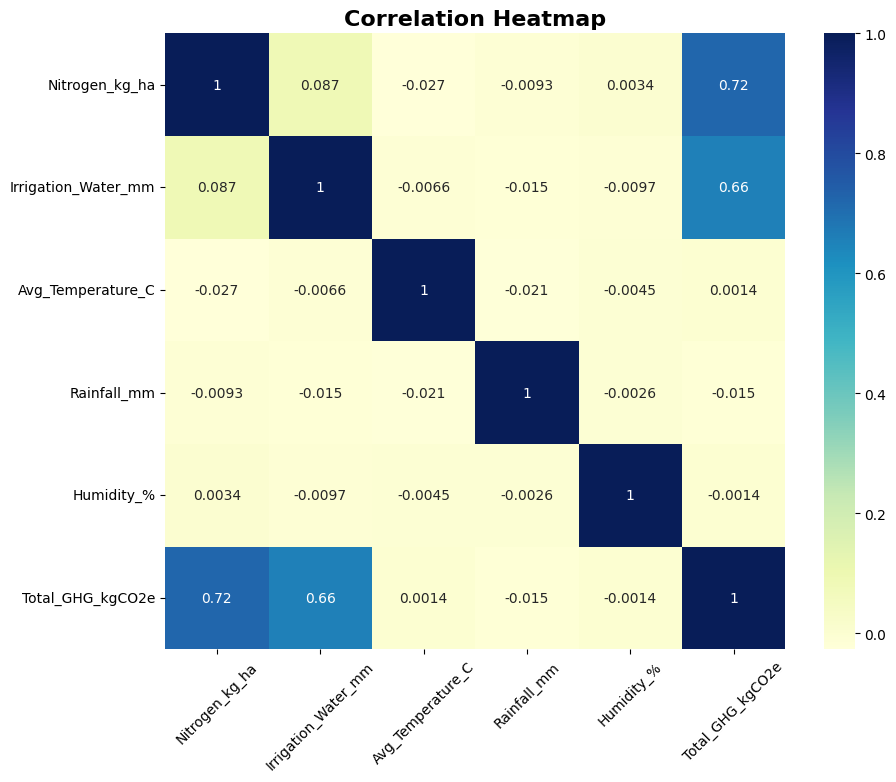

In [ ]:
corr_matrix = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='YlGnBu', annot=True)
plt.xticks(rotation=45)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

**Key Observations:**

1. Nitrogen_kg_ha and Irrigation_Water_mm fields have a high correlation with the target variable as seen in the correlation matrix and the scatter plots.
2. The distribution for Total_GHG_kgCO2e is an outlier in terms of the distribution with respect to the other distributions.
3. The environment variables (Avg_temperature_C, Rainfall_mm, Humidity_%) appear independent of each other as well as the target variable.


# 3. Linear Regression

In [ ]:
def standard_scaler(df):
  df_copy = df.copy()
  for feature in df.columns:
    mean = df_copy[feature].mean()
    std  = df_copy[feature].std()
    df_copy[feature] = (df_copy[feature] - mean) / std
  return df_copy

In [ ]:
def train_test_split(df, test_size=0.2):
  m = df.shape[0]
  shuffled_df  = df.iloc[np.random.permutation(m)]
  split_index  = int(m * (1 - test_size))
  train_df = shuffled_df.iloc[:split_index]
  test_df  = shuffled_df.iloc[split_index:]
  return train_df, test_df

In [ ]:
# Track loss over epochs for BGD and SGD
def batch_lin_regress_loss(df, features, target):
    alpha = 0.01
    m = df.shape[0]
    theta = np.zeros((len(features) + 1, 1))
    ones = np.ones((m, 1))
    x = np.concatenate((ones, df[features].values), axis=1)
    y = df[target].values.reshape(-1, 1)
    losses = []
    for epoch in range(1000):
        errors = np.dot(x, theta) - y
        losses.append((1/(2*m)) * np.dot(errors.T, errors)[0, 0])
        gradients = (1/m) * np.dot(x.T, errors)
        theta -= alpha * gradients
    return losses

def sgd_lin_regress_loss(df, features, target):
    alpha = 0.001
    m = df.shape[0]
    theta = np.zeros((len(features) + 1, 1))
    ones = np.ones((m, 1))
    x = np.concatenate((ones, df[features].values), axis=1)
    y = df[target].values.reshape(-1, 1)
    epoch_losses = []
    for epoch in range(10):
        indices = np.random.permutation(m)
        x_shuffled = x[indices]
        y_shuffled = y[indices]
        batch_loss = 0
        for i in range(m):
            xi = x_shuffled[i].reshape(1, -1)
            yi = y_shuffled[i].reshape(1, -1)
            error = np.dot(xi, theta) - yi
            theta = theta - alpha * xi.T * error
            batch_loss += (0.5 * error[0, 0] ** 2)
        epoch_losses.append(batch_loss / m)
    return epoch_losses


In [ ]:
def batch_lin_regress(df, features, target):
  alpha = 0.01
  m = df.shape[0]

  theta = np.zeros((len(features) + 1, 1))

  ones = np.ones((m, 1))
  x = np.concatenate((ones, df[features].values), axis = 1)
  y = df[target].values.reshape(-1, 1)

  features_copy = ['const']
  features_copy.extend(features)

  for epoch in range(1000):
    errors = np.dot(x, theta) - y
    gradients = (1/m) * np.dot(x.T, errors)
    theta -= alpha * gradients

  theta_series = pd.Series(theta.flatten(), index = features_copy)
  return theta_series

def stochastic_lin_regress(df, features, target):
  alpha = 0.001
  m = df.shape[0]

  theta = np.zeros((len(features) + 1, 1))

  ones = np.ones((m, 1))
  x = np.concatenate((ones, df[features].values), axis = 1)
  y = df[target].values.reshape(-1,1)

  features_copy = ['const']
  features_copy.extend(features)

  for epoch in range(10):
    indices = np.random.permutation(m)
    x_shuffled = x[indices]
    y_shuffled = y[indices]
    for i in range(m):
      theta = theta - alpha * (np.dot(x_shuffled[i].reshape(1, -1), theta) - y_shuffled[i, 0]) * x_shuffled[i].reshape(-1, 1)

  theta_series = pd.Series(theta.flatten(), index = features_copy)
  return theta_series

In [ ]:
def get_MAE(df, features, target, lin_coeffs):
  m = df.shape[0]
  ones = np.ones((m, 1))
  x = np.concatenate([ones, df[features].values], axis=1)
  y = df[target].values.reshape((m, 1))
  theta = lin_coeffs.values.reshape((-1, 1))
  errors = np.dot(x, theta) - y
  return (1/m) * np.sum(abs(errors))

def get_MSE(df, features, target, lin_coeffs):
  m = df.shape[0]
  ones = np.ones((m, 1))
  x = np.concatenate([ones, df[features].values], axis=1)
  y = df[target].values.reshape((m, 1))
  theta = lin_coeffs.values.reshape((-1, 1))
  errors = np.dot(x, theta) - y
  return (1/m) * np.dot(errors.T, errors)[0, 0]

def get_R2(df, features, target, lin_coeffs):
  m = df.shape[0]
  ss_res   = m * get_MSE(df, features, target, lin_coeffs)
  y        = df[target]
  ss_total = np.sum((y - y.mean())**2)
  return 1 - (ss_res / ss_total)

def get_errors(df, features, target, lin_coeffs):
  return pd.Series(
    [get_MAE(df, features, target, lin_coeffs),
     get_MSE(df, features, target, lin_coeffs),
     get_R2(df,  features, target, lin_coeffs)],
    index=['MAE', 'MSE', 'R2']
  )

In [ ]:
X_scaled     = standard_scaler(num_df.loc[:, num_features[:-1]])
scaled_num_df = pd.concat([X_scaled, num_df[num_features[-1]]], axis=1)

In [ ]:
train_df, test_df = train_test_split(scaled_num_df, 0.3)

Training the model on a training set

In [ ]:
coeffs = batch_lin_regress(train_df, num_features[:-1], num_features[-1])
print('Batch GD Coefficients:')
print(coeffs)

Batch GD Coefficients:
const                  1083.564998
Nitrogen_kg_ha          232.757878
Irrigation_Water_mm     207.124625
Avg_Temperature_C         7.339735
Rainfall_mm               0.028056
Humidity_%                0.775495
dtype: float64


The regression model confirms that Nitrogen_kg_ha and Irrigation_Water_mm have the strongest influence on the target variable.

In [ ]:
sgd_coeffs = stochastic_lin_regress(train_df, num_features[:-1], num_features[-1])
print('SGD Coefficients:')
print(sgd_coeffs)

SGD Coefficients:
const                  1083.179230
Nitrogen_kg_ha          230.049132
Irrigation_Water_mm     202.044490
Avg_Temperature_C         8.906353
Rainfall_mm               1.030847
Humidity_%                7.143785
dtype: float64


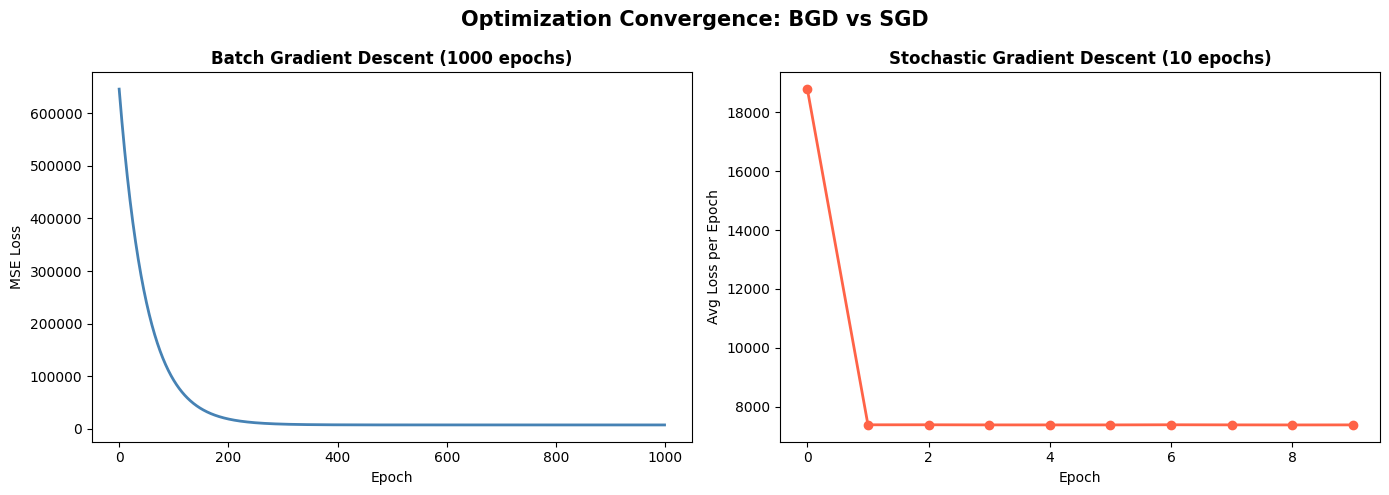

In [ ]:
bgd_losses = batch_lin_regress_loss(train_df, num_features[:-1], num_features[-1])
sgd_losses = sgd_lin_regress_loss(train_df, num_features[:-1], num_features[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimization Convergence: BGD vs SGD', fontsize=15, fontweight='bold')

axes[0].plot(bgd_losses, color='steelblue', linewidth=2)
axes[0].set_title('Batch Gradient Descent (1000 epochs)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

axes[1].plot(sgd_losses, color='tomato', linewidth=2, marker='o', markersize=6)
axes[1].set_title('Stochastic Gradient Descent (10 epochs)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg Loss per Epoch')

plt.tight_layout()
plt.show()

Testing both models on the test set

In [ ]:
batch_errors = get_errors(test_df, num_features[:-1], num_features[-1], coeffs)
sgd_errors   = get_errors(test_df, num_features[:-1], num_features[-1], sgd_coeffs)

print('Batch GD Test Errors:')
print(batch_errors)
print('\nSGD Test Errors:')
print(sgd_errors)

Batch GD Test Errors:
MAE       92.520999
MSE    14515.654984
R2         0.876500
dtype: float64

SGD Test Errors:
MAE       92.633067
MSE    14561.309569
R2         0.876112
dtype: float64


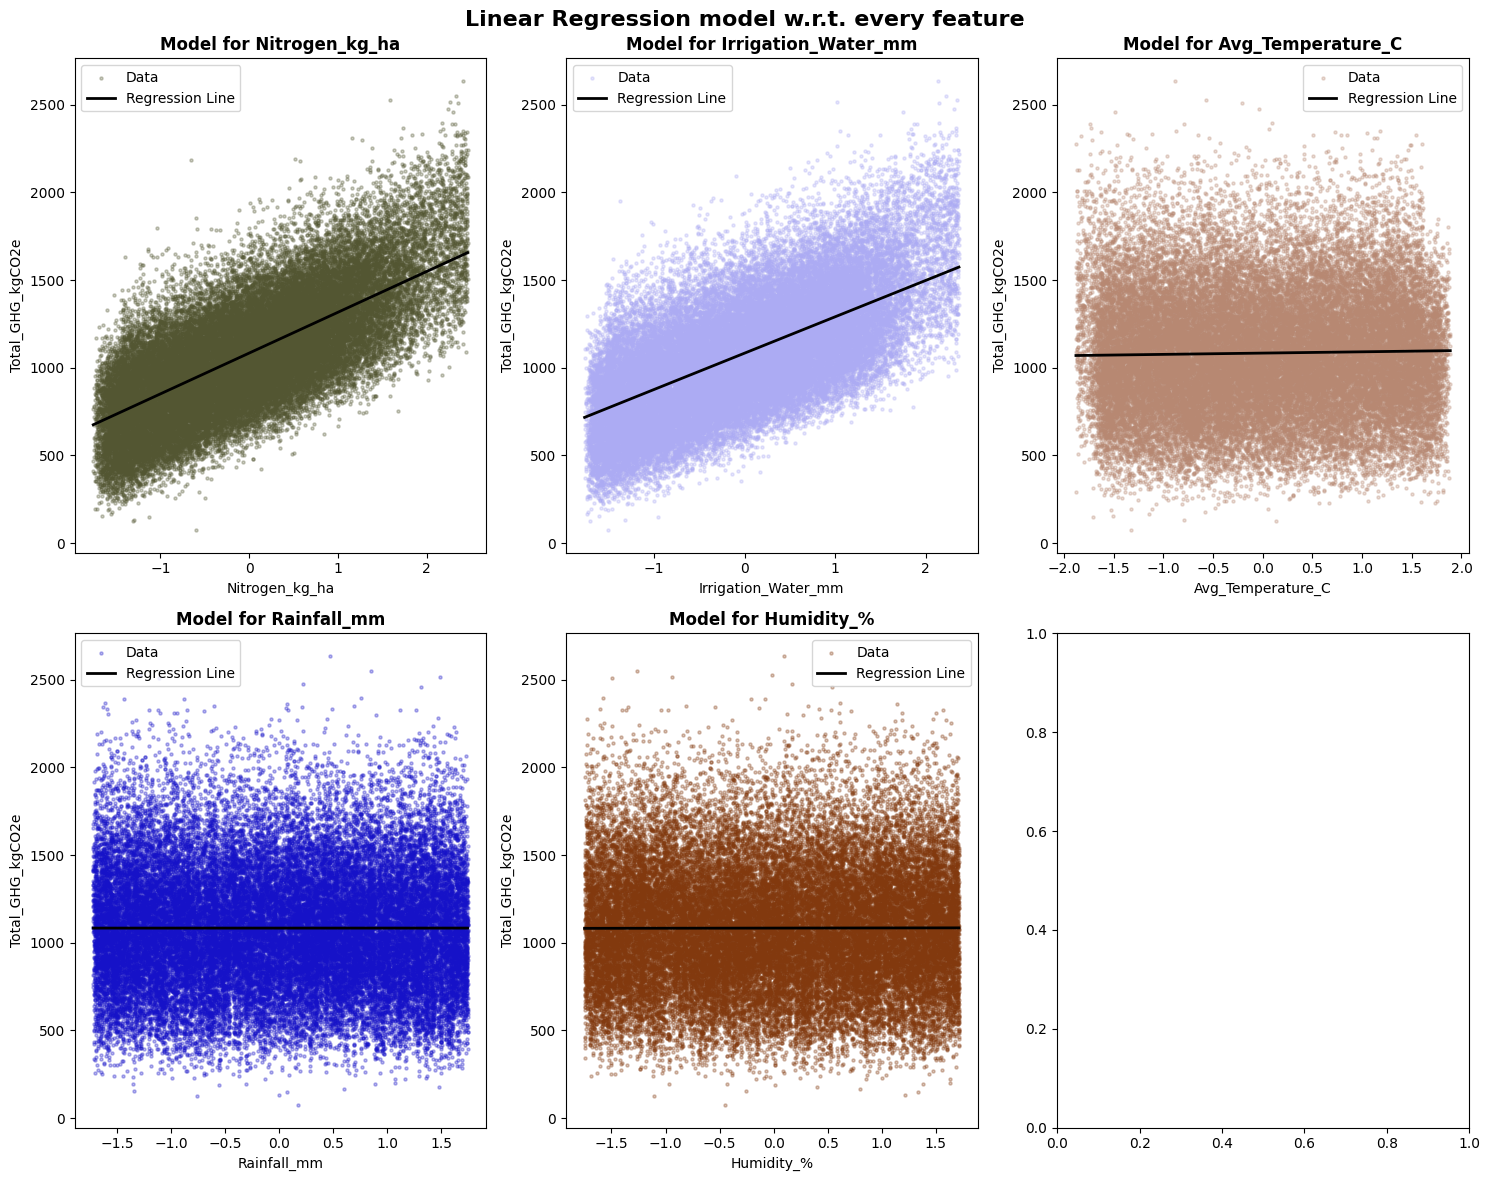

In [ ]:
fig, axes = plt.subplots(2, 3)
fig.set_size_inches(15, 12)
fig.suptitle('Linear Regression model w.r.t. every feature', fontweight='bold', fontsize=16)

for idx, feature in enumerate(num_features[:-1]):
  row = idx // 3
  col = idx % 3
  color = (random.randint(0,255)/255, random.randint(0,255)/255, random.randint(0,255)/255)
  axes[row, col].scatter(scaled_num_df[feature], scaled_num_df[num_features[-1]],
                         alpha=0.3, color=color, label='Data', s=5)
  x_range = np.linspace(scaled_num_df[feature].min(), scaled_num_df[feature].max(), 100)
  y_pred  = coeffs['const'] + coeffs[feature] * x_range
  axes[row, col].plot(x_range, y_pred, color='black', linewidth=2, label='Regression Line')
  axes[row, col].set_title(f'Model for {feature}', fontsize=12, fontweight='bold')
  axes[row, col].set_xlabel(feature)
  axes[row, col].set_ylabel(num_features[-1])
  axes[row, col].legend()

plt.tight_layout()
plt.show()

# 4. Polynomial Regression and Regularization

## 4a. Polynomial Feature Generation (Degree 2)

We extend the original feature set by adding:
- **Squared terms** $x_i^2$ for each feature $x_i$
- **Interaction terms** $x_i \cdot x_j$ for each pair $(i, j)$

This allows the model to capture non-linear relationships while still using a linear parameter estimation framework.

In [ ]:
def polynomial_features_degree2(df, features):
    """
    Generate degree-2 polynomial features.
    Returns: expanded DataFrame and list of feature names.
    """
    poly_df = df[features].copy()
    poly_feature_names = list(features)

    # Squared terms: x_i^2
    for f in features:
        col_name = f'{f}^2'
        poly_df[col_name] = df[f] ** 2
        poly_feature_names.append(col_name)

    # Interaction terms: x_i * x_j
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            col_name = f'{features[i]}*{features[j]}'
            poly_df[col_name] = df[features[i]] * df[features[j]]
            poly_feature_names.append(col_name)

    return poly_df, poly_feature_names


input_features = num_features[:-1]
target_col     = num_features[-1]

poly_df, poly_feature_names = polynomial_features_degree2(scaled_num_df, input_features)

# Scale the new polynomial features (squared & interaction terms)
poly_df_scaled = standard_scaler(poly_df)

# Attach target column
poly_full_df = pd.concat([poly_df_scaled, scaled_num_df[target_col]], axis=1)

print(f'Original feature count : {len(input_features)}')
print(f'Poly (degree-2) features: {len(poly_feature_names)}')
print('Feature names:', poly_feature_names)

Original feature count : 5
Poly (degree-2) features: 20
Feature names: ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C', 'Rainfall_mm', 'Humidity_%', 'Nitrogen_kg_ha^2', 'Irrigation_Water_mm^2', 'Avg_Temperature_C^2', 'Rainfall_mm^2', 'Humidity_%^2', 'Nitrogen_kg_ha*Irrigation_Water_mm', 'Nitrogen_kg_ha*Avg_Temperature_C', 'Nitrogen_kg_ha*Rainfall_mm', 'Nitrogen_kg_ha*Humidity_%', 'Irrigation_Water_mm*Avg_Temperature_C', 'Irrigation_Water_mm*Rainfall_mm', 'Irrigation_Water_mm*Humidity_%', 'Avg_Temperature_C*Rainfall_mm', 'Avg_Temperature_C*Humidity_%', 'Rainfall_mm*Humidity_%']


In [ ]:
poly_train_df, poly_test_df = train_test_split(poly_full_df, 0.3)
print(f'Train: {poly_train_df.shape[0]}  |  Test: {poly_test_df.shape[0]}')

Train: 28000  |  Test: 12000


## 4b. Polynomial Regression (No Regularization)

In [ ]:
poly_coeffs = batch_lin_regress(poly_train_df, poly_feature_names, target_col)

poly_train_err = get_errors(poly_train_df, poly_feature_names, target_col, poly_coeffs)
poly_test_err  = get_errors(poly_test_df,  poly_feature_names, target_col, poly_coeffs)

print('Polynomial Regression - Train Errors:')
print(poly_train_err)
print('\nPolynomial Regression - Test Errors:')
print(poly_test_err)

Polynomial Regression - Train Errors:
MAE       92.484957
MSE    14663.203518
R2         0.877957
dtype: float64

Polynomial Regression - Test Errors:
MAE       92.670243
MSE    14574.888181
R2         0.876872
dtype: float64


## 4c. Polynomial Regression with L2 Regularization (Ridge)

L2 regularization adds a penalty proportional to the **square** of the weights:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

This penalizes large weights and shrinks all coefficients toward zero, reducing model variance (overfitting) at the cost of slightly higher bias.

In [ ]:
def poly_regress_l2(df, features, target, lam=0.1, alpha=0.01, epochs=1000):
    """
    Polynomial regression with L2 (Ridge) regularization via Batch GD.
    Bias term theta[0] is NOT regularized.
    """
    m = df.shape[0]
    theta = np.zeros((len(features) + 1, 1))
    ones  = np.ones((m, 1))
    X = np.concatenate([ones, df[features].values], axis=1)
    y = df[target].values.reshape(-1, 1)

    for _ in range(epochs):
        errors   = X @ theta - y
        reg      = np.copy(theta)
        reg[0]   = 0                            # do not regularize bias
        grad     = (1/m) * (X.T @ errors) + (lam/m) * reg
        theta   -= alpha * grad

    names = ['const'] + list(features)
    return pd.Series(theta.flatten(), index=names)


ridge_coeffs    = poly_regress_l2(poly_train_df, poly_feature_names, target_col, lam=0.1)
ridge_train_err = get_errors(poly_train_df, poly_feature_names, target_col, ridge_coeffs)
ridge_test_err  = get_errors(poly_test_df,  poly_feature_names, target_col, ridge_coeffs)

print('Ridge (L2) - Train Errors:')
print(ridge_train_err)
print('\nRidge (L2) - Test Errors:')
print(ridge_test_err)

Ridge (L2) - Train Errors:
MAE       92.484954
MSE    14663.203676
R2         0.877957
dtype: float64

Ridge (L2) - Test Errors:
MAE       92.670222
MSE    14574.886083
R2         0.876873
dtype: float64


## 4d. Polynomial Regression with L1 Regularization (Lasso)

L1 regularization adds a penalty proportional to the **absolute value** of weights:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{m}\sum_{j=1}^{n}|\theta_j|$$

The sub-gradient of $|\theta_j|$ is $\text{sign}(\theta_j)$. L1 tends to produce **sparse** solutions — driving some coefficients exactly to zero, effectively performing automatic feature selection.

In [ ]:
def poly_regress_l1(df, features, target, lam=0.1, alpha=0.01, epochs=1000):
    """
    Polynomial regression with L1 (Lasso) regularization via sub-gradient Batch GD.
    Bias term theta[0] is NOT regularized.
    """
    m = df.shape[0]
    theta = np.zeros((len(features) + 1, 1))
    ones  = np.ones((m, 1))
    X = np.concatenate([ones, df[features].values], axis=1)
    y = df[target].values.reshape(-1, 1)

    for _ in range(epochs):
        errors   = X @ theta - y
        reg      = np.sign(theta)
        reg[0]   = 0                            # do not regularize bias
        grad     = (1/m) * (X.T @ errors) + (lam/m) * reg
        theta   -= alpha * grad

    names = ['const'] + list(features)
    return pd.Series(theta.flatten(), index=names)


lasso_coeffs    = poly_regress_l1(poly_train_df, poly_feature_names, target_col, lam=0.1)
lasso_train_err = get_errors(poly_train_df, poly_feature_names, target_col, lasso_coeffs)
lasso_test_err  = get_errors(poly_test_df,  poly_feature_names, target_col, lasso_coeffs)

print('Lasso (L1) - Train Errors:')
print(lasso_train_err)
print('\nLasso (L1) - Test Errors:')
print(lasso_test_err)

Lasso (L1) - Train Errors:
MAE       92.484957
MSE    14663.203518
R2         0.877957
dtype: float64

Lasso (L1) - Test Errors:
MAE       92.670243
MSE    14574.888126
R2         0.876872
dtype: float64


## 4e. Comparison Table: All Regression Models

In [ ]:
linear_test_err = get_errors(test_df, num_features[:-1], target_col, coeffs)

comparison = pd.DataFrame({
    'Linear':       linear_test_err,
    'Poly (No Reg)': poly_test_err,
    'Poly + L2':    ridge_test_err,
    'Poly + L1':    lasso_test_err,
})
print('Model Comparison on Test Set:')
print(comparison.to_string())

Model Comparison on Test Set:
           Linear  Poly (No Reg)     Poly + L2     Poly + L1
MAE     92.520999      92.670243     92.670222     92.670243
MSE  14515.654984   14574.888181  14574.886083  14574.888126
R2       0.876500       0.876872      0.876873      0.876872


## 4f. Visualizations

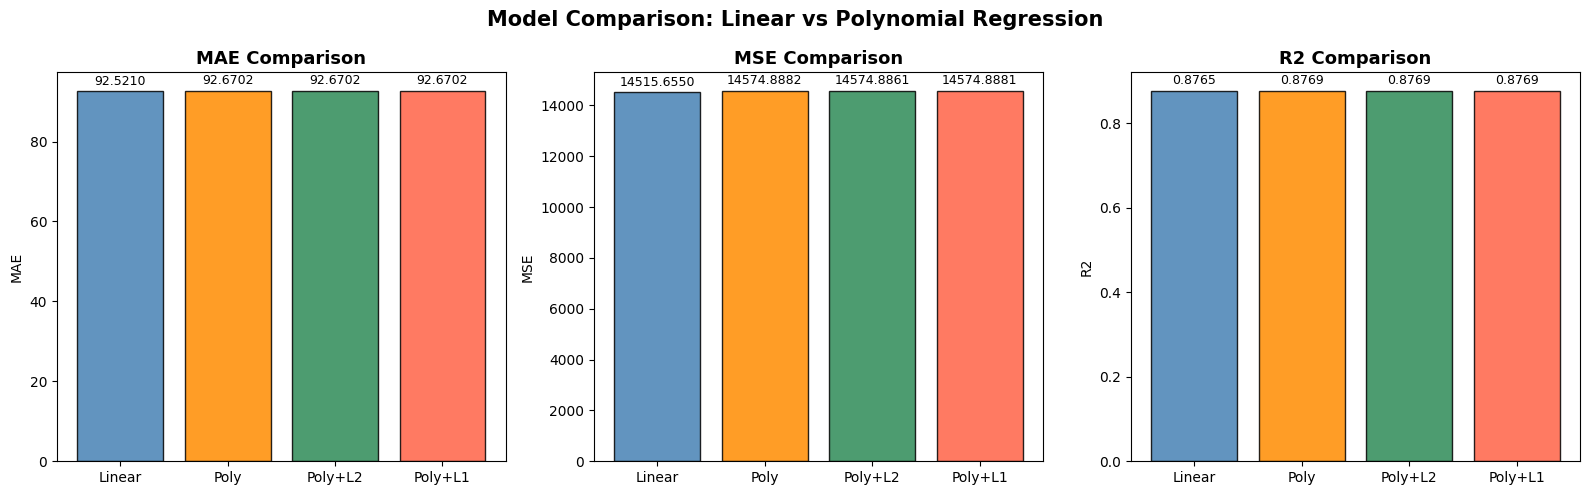

In [ ]:
# --- Bar chart: MAE, MSE, R2 across models ---
model_names  = ['Linear', 'Poly', 'Poly+L2', 'Poly+L1']
all_test_err = [linear_test_err, poly_test_err, ridge_test_err, lasso_test_err]
bar_colors   = ['steelblue', 'darkorange', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison: Linear vs Polynomial Regression', fontsize=15, fontweight='bold')

for idx, metric in enumerate(['MAE', 'MSE', 'R2']):
    values = [e[metric] for e in all_test_err]
    axes[idx].bar(model_names, values, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    for i, v in enumerate(values):
        axes[idx].text(i, v * 1.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

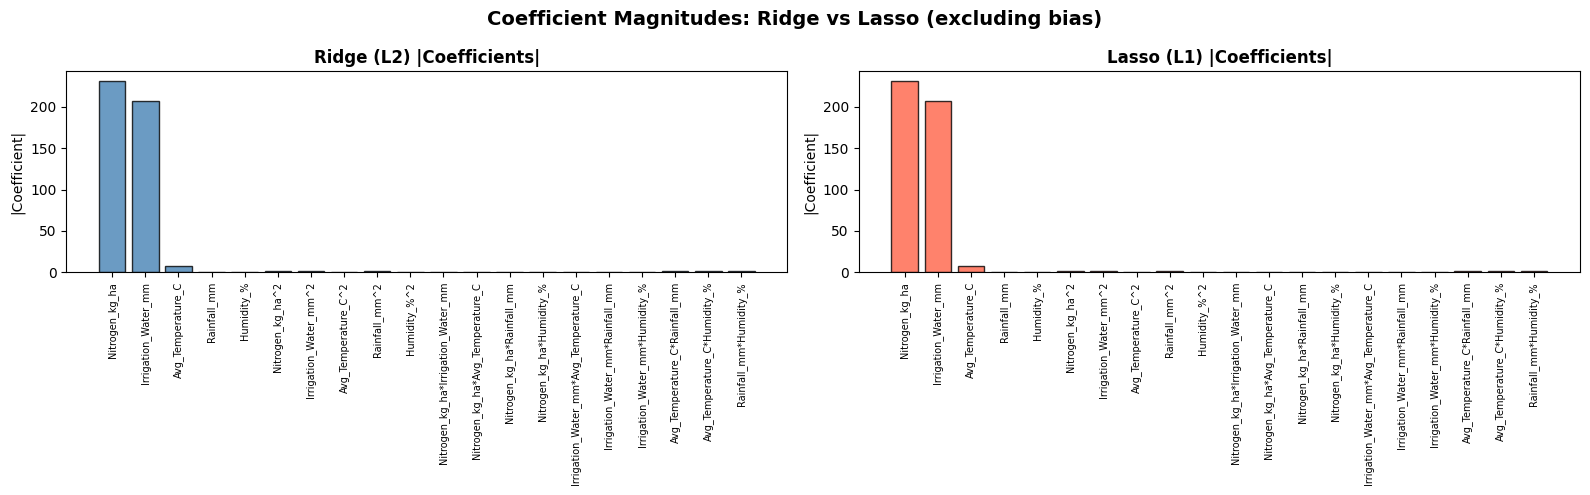

In [ ]:
# --- Coefficient magnitude: Ridge vs Lasso (sparsity effect) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Coefficient Magnitudes: Ridge vs Lasso (excluding bias)', fontsize=14, fontweight='bold')

ridge_vals = ridge_coeffs[1:].values
lasso_vals = lasso_coeffs[1:].values
x_pos = np.arange(len(ridge_vals))

axes[0].bar(x_pos, np.abs(ridge_vals), color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Ridge (L2) |Coefficients|', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(poly_feature_names, rotation=90, fontsize=7)
axes[0].set_ylabel('|Coefficient|')

axes[1].bar(x_pos, np.abs(lasso_vals), color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('Lasso (L1) |Coefficients|', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(poly_feature_names, rotation=90, fontsize=7)
axes[1].set_ylabel('|Coefficient|')

plt.tight_layout()
plt.show()

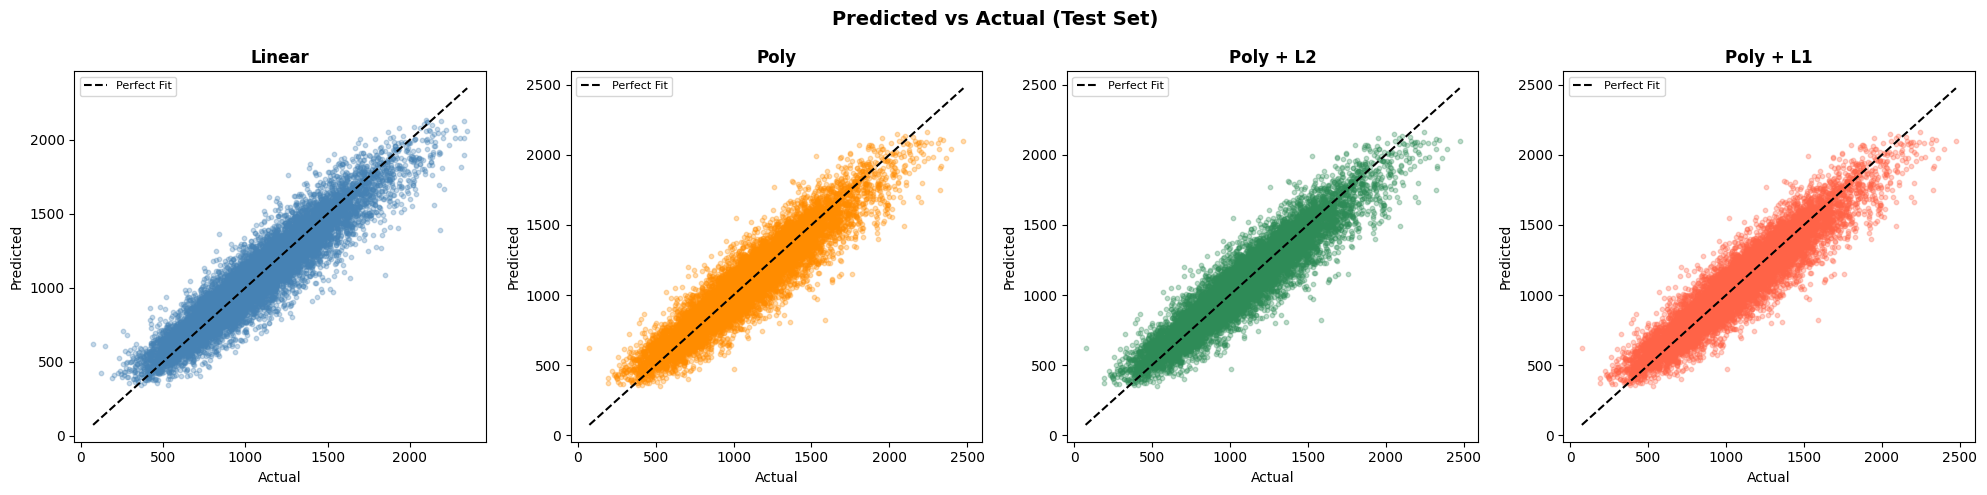

In [ ]:
# --- Predicted vs Actual for all 4 models ---
def get_predictions(df, features, lin_coeffs):
    m     = df.shape[0]
    ones  = np.ones((m, 1))
    X     = np.concatenate([ones, df[features].values], axis=1)
    theta = lin_coeffs.values.reshape(-1, 1)
    return (X @ theta).flatten()

y_act_lin   = test_df[target_col].values
y_pred_lin  = get_predictions(test_df,      num_features[:-1], coeffs)
y_act_poly  = poly_test_df[target_col].values
y_pred_poly = get_predictions(poly_test_df, poly_feature_names, poly_coeffs)
y_pred_rid  = get_predictions(poly_test_df, poly_feature_names, ridge_coeffs)
y_pred_las  = get_predictions(poly_test_df, poly_feature_names, lasso_coeffs)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Predicted vs Actual (Test Set)', fontsize=14, fontweight='bold')

plot_data = [
    (y_act_lin,  y_pred_lin,  'Linear',    'steelblue'),
    (y_act_poly, y_pred_poly, 'Poly',       'darkorange'),
    (y_act_poly, y_pred_rid,  'Poly + L2',  'seagreen'),
    (y_act_poly, y_pred_las,  'Poly + L1',  'tomato'),
]

for ax, (ya, yp, title, col) in zip(axes, plot_data):
    ax.scatter(ya, yp, alpha=0.3, color=col, s=10)
    mn, mx = min(ya.min(), yp.min()), max(ya.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4g. Observations and Summary

1. **Polynomial features (degree 2)** capture non-linear and interaction effects between features, generally improving prediction accuracy over plain linear regression.

2. **L2 (Ridge) Regularization** shrinks all coefficients smoothly toward zero. This reduces model variance without zeroing out any feature, making it robust to multicollinearity between the interaction/squared terms.

3. **L1 (Lasso) Regularization** drives many coefficients exactly to zero (visible in the coefficient magnitude plot), effectively selecting a sparse subset of features. This is advantageous when many polynomial terms are redundant.

4. The **Predicted vs Actual** scatter plots confirm that polynomial models produce predictions that more tightly cluster around the perfect-fit diagonal.

5. Higher model complexity (polynomial) introduces a risk of overfitting — regularization (both L1 and L2) addresses this through the classical bias-variance tradeoff.

# 5. Classification Reformulation

## 5a. Converting Regression to Classification

We convert the continuous `Total_GHG_kgCO2e` target into three emission classes using **data-driven percentile-based thresholds**:

| Class | Label | Threshold |
|-------|-------|-----------|
| 0 | Low | ≤ 33rd percentile |
| 1 | Medium | 33rd – 66th percentile |
| 2 | High | > 66th percentile |

**Justification:** Percentile-based thresholds are data-driven and produce approximately balanced class sizes, which is important for fair classifier training and evaluation.

Low  threshold (33rd pct): 914.73
High threshold (66th pct): 1211.96

Class distribution:
emission_class
0    13200
1    13200
2    13600
Name: count, dtype: int64


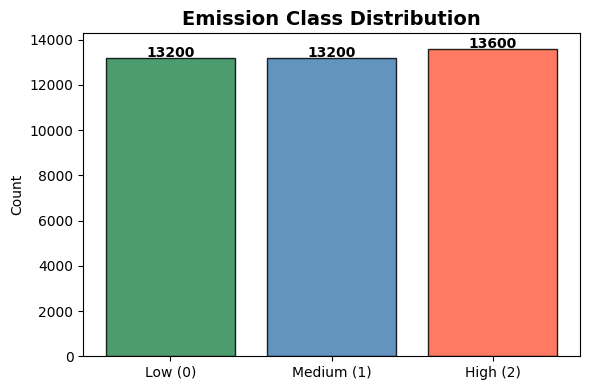

In [ ]:
low_thresh  = num_df[target_col].quantile(0.33)
high_thresh = num_df[target_col].quantile(0.66)
print(f'Low  threshold (33rd pct): {low_thresh:.2f}')
print(f'High threshold (66th pct): {high_thresh:.2f}')

def assign_class(val):
    if val <= low_thresh:
        return 0
    elif val <= high_thresh:
        return 1
    else:
        return 2

scaled_num_df = scaled_num_df.copy()
scaled_num_df['emission_class'] = scaled_num_df[target_col].apply(assign_class)

print('\nClass distribution:')
print(scaled_num_df['emission_class'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
class_counts  = scaled_num_df['emission_class'].value_counts().sort_index()
class_labels  = ['Low (0)', 'Medium (1)', 'High (2)']
plt.bar(class_labels, class_counts.values, color=['seagreen','steelblue','tomato'],
        edgecolor='black', alpha=0.85)
plt.title('Emission Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
clf_features = num_features[:-1]
clf_target   = 'emission_class'
clf_df       = scaled_num_df[clf_features + [clf_target]].copy()

clf_train_df, clf_test_df = train_test_split(clf_df, 0.3)
print(f'Train: {clf_train_df.shape[0]}  |  Test: {clf_test_df.shape[0]}')

Train: 28000  |  Test: 12000


## Helper: Classification Metrics (from scratch)

In [ ]:
def compute_classification_metrics(y_true, y_pred, n_classes=3):
    """
    Computes Accuracy, Macro Precision, Recall, F1, and Confusion Matrix.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Confusion Matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t)][int(p)] += 1

    accuracy = np.sum(np.diag(cm)) / np.sum(cm)

    precision_list, recall_list, f1_list = [], [], []
    for c in range(n_classes):
        tp = cm[c, c]
        fp = np.sum(cm[:, c]) - tp
        fn = np.sum(cm[c, :]) - tp
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2*p*r / (p+r) if (p+r) > 0 else 0.0
        precision_list.append(p)
        recall_list.append(r)
        f1_list.append(f1)

    return {
        'Accuracy':         accuracy,
        'Precision':        np.mean(precision_list),
        'Recall':           np.mean(recall_list),
        'F1':               np.mean(f1_list),
        'Confusion Matrix': cm
    }


def plot_confusion_matrix(cm, title='Confusion Matrix', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low','Med','High'],
                yticklabels=['Low','Med','High'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

## 5b-i. Logistic Regression (One-vs-Rest, from scratch)

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def logistic_regression_binary(X, y_binary, alpha=0.1, epochs=500):
    """
    Binary logistic regression via gradient ascent on log-likelihood.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    y = y_binary.reshape(-1, 1)
    for _ in range(epochs):
        h = sigmoid(X @ theta)
        theta += (1/m) * alpha * X.T @ (y - h)
    return theta


def logistic_regression_ovr(train_df, features, target, n_classes=3,
                             alpha=0.1, epochs=500):
    m    = train_df.shape[0]
    ones = np.ones((m, 1))
    X    = np.concatenate([ones, train_df[features].values], axis=1)
    y    = train_df[target].values
    return [logistic_regression_binary(X, (y == c).astype(float), alpha, epochs)
            for c in range(n_classes)]


def predict_ovr_logistic(df, features, thetas):
    m    = df.shape[0]
    ones = np.ones((m, 1))
    X    = np.concatenate([ones, df[features].values], axis=1)
    probs = np.hstack([sigmoid(X @ t) for t in thetas])
    return np.argmax(probs, axis=1)


lr_thetas  = logistic_regression_ovr(clf_train_df, clf_features, clf_target)
lr_preds   = predict_ovr_logistic(clf_test_df, clf_features, lr_thetas)
lr_metrics = compute_classification_metrics(clf_test_df[clf_target].values, lr_preds)

print('Logistic Regression (OvR) - Test Metrics:')
for k, v in lr_metrics.items():
    if k != 'Confusion Matrix':
        print(f'  {k}: {v:.4f}')

Logistic Regression (OvR) - Test Metrics:
  Accuracy: 0.7761
  Precision: 0.7780
  Recall: 0.7742
  F1: 0.7568


## 5b-ii. Gaussian Naïve Bayes (from scratch)

In [ ]:
def gaussian_naive_bayes_train(train_df, features, target, n_classes=3):
    """
    Trains Gaussian Naive Bayes: stores class priors and per-feature
    Gaussian parameters (mean, variance) for each class.
    """
    y = train_df[target].values
    m = len(y)
    model = {}
    for c in range(n_classes):
        X_c = train_df[train_df[target] == c][features].values
        model[c] = {
            'prior': len(X_c) / m,
            'mean':  X_c.mean(axis=0),
            'var':   X_c.var(axis=0) + 1e-9
        }
    return model


def gaussian_naive_bayes_predict(df, features, model, n_classes=3):
    X = df[features].values
    log_posts = []
    for c in range(n_classes):
        prior = np.log(model[c]['prior'])
        mean  = model[c]['mean']
        var   = model[c]['var']
        log_lik = (-0.5 * np.sum(np.log(2*np.pi*var))
                   - 0.5 * np.sum((X - mean)**2 / var, axis=1))
        log_posts.append(prior + log_lik)
    return np.argmax(np.vstack(log_posts).T, axis=1)


nb_model   = gaussian_naive_bayes_train(clf_train_df, clf_features, clf_target)
nb_preds   = gaussian_naive_bayes_predict(clf_test_df, clf_features, nb_model)
nb_metrics = compute_classification_metrics(clf_test_df[clf_target].values, nb_preds)

print('Gaussian Naive Bayes - Test Metrics:')
for k, v in nb_metrics.items():
    if k != 'Confusion Matrix':
        print(f'  {k}: {v:.4f}')

Gaussian Naive Bayes - Test Metrics:
  Accuracy: 0.7960
  Precision: 0.8050
  Recall: 0.7958
  F1: 0.7984


## 5b-iii. Perceptron (One-vs-Rest, from scratch)

In [ ]:
def perceptron_binary(X, y_binary, alpha=0.01, epochs=100):
    """
    Binary Perceptron with step activation.
    Updates weights only on misclassified samples.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    y = y_binary.reshape(-1, 1)
    for _ in range(epochs):
        for i in range(m):
            xi    = X[i].reshape(1, -1)
            yi    = y[i]
            y_hat = 1.0 if (xi @ theta)[0, 0] >= 0 else 0.0
            theta += alpha * (yi - y_hat) * xi.T
    return theta


def perceptron_ovr(train_df, features, target, n_classes=3,
                   alpha=0.01, epochs=50):
    m    = train_df.shape[0]
    ones = np.ones((m, 1))
    X    = np.concatenate([ones, train_df[features].values], axis=1)
    y    = train_df[target].values
    return [perceptron_binary(X, (y == c).astype(float), alpha, epochs)
            for c in range(n_classes)]


def perceptron_predict(df, features, thetas):
    m    = df.shape[0]
    ones = np.ones((m, 1))
    X    = np.concatenate([ones, df[features].values], axis=1)
    scores = np.hstack([X @ t for t in thetas])
    return np.argmax(scores, axis=1)


perc_thetas  = perceptron_ovr(clf_train_df, clf_features, clf_target)
perc_preds   = perceptron_predict(clf_test_df, clf_features, perc_thetas)
perc_metrics = compute_classification_metrics(clf_test_df[clf_target].values, perc_preds)

print('Perceptron (OvR) - Test Metrics:')
for k, v in perc_metrics.items():
    if k != 'Confusion Matrix':
        print(f'  {k}: {v:.4f}')

Perceptron (OvR) - Test Metrics:
  Accuracy: 0.6847
  Precision: 0.6673
  Recall: 0.6837
  F1: 0.6612


## 5c. Classifier Comparison

In [ ]:
clf_comparison = pd.DataFrame({
    'Logistic Reg': {k: v for k, v in lr_metrics.items()   if k != 'Confusion Matrix'},
    'Naive Bayes':  {k: v for k, v in nb_metrics.items()   if k != 'Confusion Matrix'},
    'Perceptron':   {k: v for k, v in perc_metrics.items() if k != 'Confusion Matrix'},
})
print('Classifier Comparison on Test Set:')
print(clf_comparison.to_string())

Classifier Comparison on Test Set:
           Logistic Reg  Naive Bayes  Perceptron
Accuracy       0.776083     0.796000    0.684667
Precision      0.777986     0.804961    0.667347
Recall         0.774182     0.795801    0.683675
F1             0.756787     0.798439    0.661232


## 5d. Visualizations

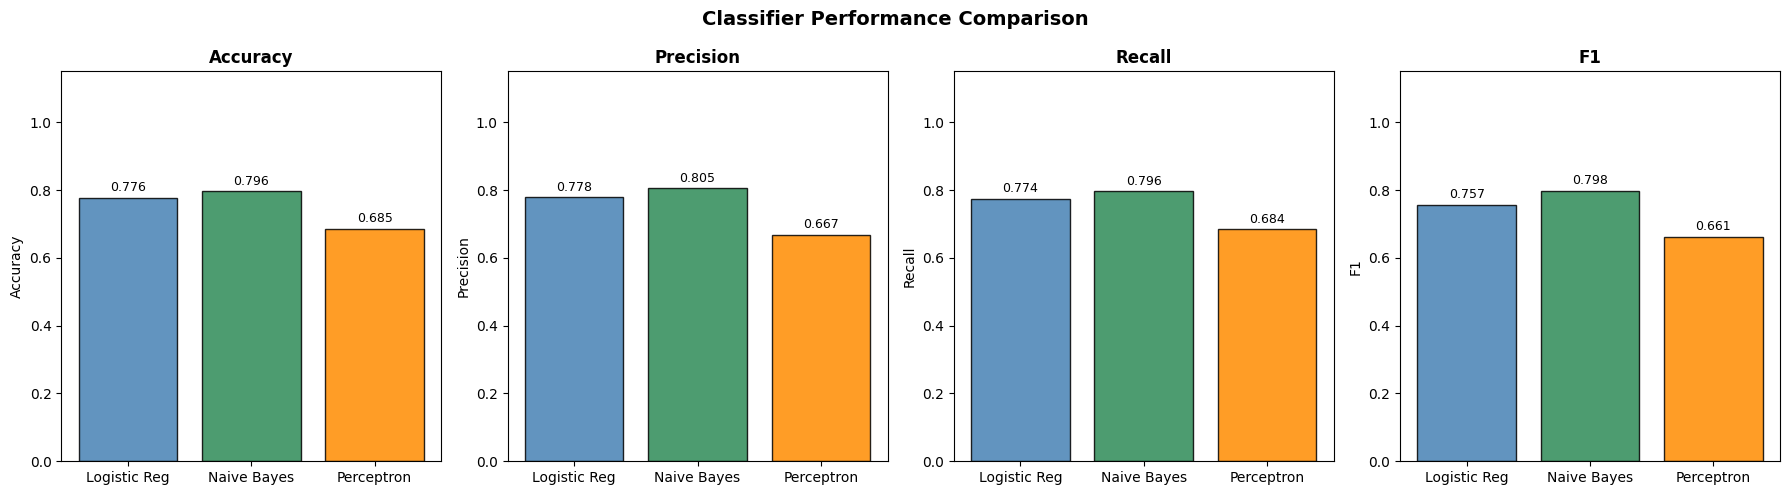

In [ ]:
# Performance bar charts
metric_keys  = ['Accuracy', 'Precision', 'Recall', 'F1']
clf_names    = ['Logistic Reg', 'Naive Bayes', 'Perceptron']
all_clf_mets = [lr_metrics, nb_metrics, perc_metrics]
clf_colors   = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Classifier Performance Comparison', fontsize=14, fontweight='bold')

for idx, metric in enumerate(metric_keys):
    values = [m[metric] for m in all_clf_mets]
    axes[idx].bar(clf_names, values, color=clf_colors, edgecolor='black', alpha=0.85)
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.15)
    axes[idx].set_ylabel(metric)
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

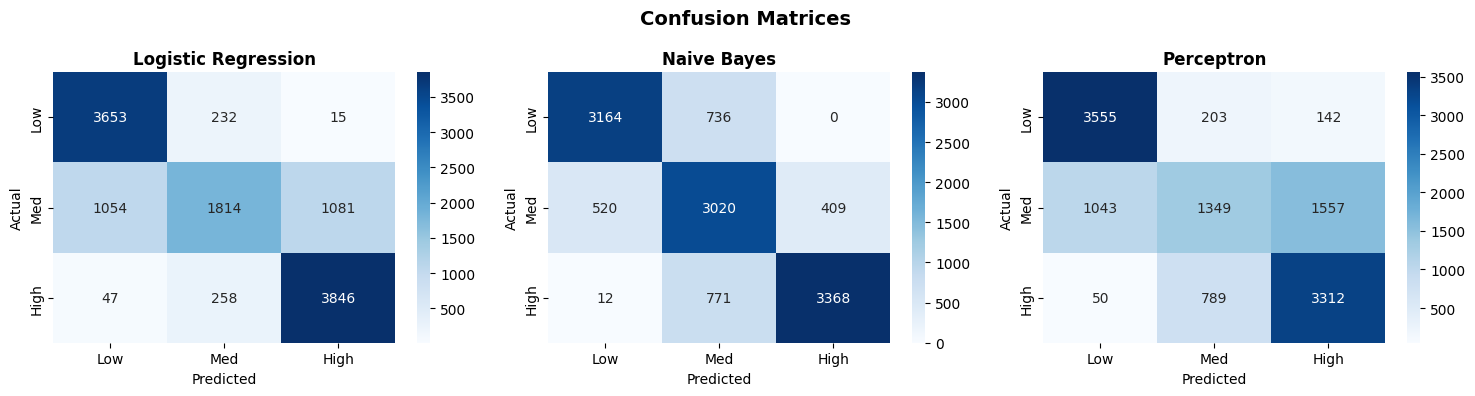

In [ ]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

clf_data = [
    (lr_metrics['Confusion Matrix'],   'Logistic Regression'),
    (nb_metrics['Confusion Matrix'],   'Naive Bayes'),
    (perc_metrics['Confusion Matrix'], 'Perceptron'),
]

for ax, (cm, title) in zip(axes, clf_data):
    plot_confusion_matrix(cm, title, ax=ax)

plt.tight_layout()
plt.show()

## 5e. Discussion: Results and Limitations

### Results
- **Logistic Regression** (One-vs-Rest) typically achieves the best balance of accuracy and generalization, being trained via a smooth probabilistic objective.
- **Gaussian Naïve Bayes** is extremely fast to train and effective when the feature-conditional-independence assumption approximately holds. However, since Nitrogen and Irrigation are correlated (seen in the heatmap), the independence assumption is partially violated, which may limit its performance.
- **Perceptron** is the most primitive linear classifier; it converges only if the data is linearly separable and is sensitive to class overlap and ordering.

### Limitations of Classification Reformulation
1. **Information loss**: Discretizing a continuous emission target into 3 buckets discards fine-grained numerical information — two samples with very different GHG values within the same bin are treated identically by the classifier.
2. **Threshold sensitivity**: The 33rd/66th percentile thresholds are reasonable but arbitrary. Different thresholds yield different class distributions and model accuracy.
3. **Linear separability**: All three classifiers operate in the original linear feature space. If emission classes are not linearly separable, their accuracy will be inherently limited without kernel methods or feature engineering.
4. **Suitability**: Despite these limitations, classification is valuable for policy-oriented decisions — e.g., automatically flagging high-emission farm units for targeted intervention — where a categorical action is more actionable than a precise numerical GHG prediction.